# 05 - Feature Engineering

### Objective

The goal of this notebook is to transform cleaned historical stock data into meaningful features that can later be used for machine learning.

Feature engineering is applied to all 8 US and Indian stocks using a reusable feature engineering pipeline.

### Features

- Daily Return
- Adjusted Daily Return
- Lag Returns
- Simple Moving Averages (SMA)
- Exponential Moving Average (EMA)
- Rolling Volatility
- Volume Change
- Intraday Price Features
- Relative Strength Index (RSI)
- MACD

In [16]:
import sys

sys.path.append("../src")

from feature_engineering import feature_engineering

In [17]:
import os

os.makedirs("../data/processed", exist_ok=True)

In [18]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns

In [19]:
stocks = [
    "AAPL",
    "MSFT",
    "NVDA",
    "AMZN",
    "RELIANCE.NS",
    "TCS.NS",
    "HDFCBANK.NS",
    "INFY.NS"
]

## Apply Feature Engineering

The reusable `feature_engineering()` function is applied to each cleaned stock dataset.

The processed datasets are stored in the `data/processed/` directory.

In [20]:
feature_data = {}

for stock in stocks:
    
    feature_data[stock] = feature_engineering(
        f"../data/cleaned/{stock}.csv",
        f"../data/processed/{stock}_features.csv"
    )
    print(f"{stock} feature engineering completed.")

AAPL feature engineering completed.
MSFT feature engineering completed.
NVDA feature engineering completed.
AMZN feature engineering completed.
RELIANCE.NS feature engineering completed.
TCS.NS feature engineering completed.
HDFCBANK.NS feature engineering completed.
INFY.NS feature engineering completed.


## Inspect Processed Data

Apple (AAPL) is used as an example to verify the features generated by the pipeline.

In [21]:
df = feature_data["AAPL"]

print("Columns:")
print(df.columns.tolist())

print("\nShape:")
print(df.shape)

print("\nAdjusted Close preview:")
display(
    df[
        [
            "Date",
            "Close",
            "Adj Close",
            "Daily_Return",
            "Adj_Daily_Return"
        ]
    ].head(10)
)

Columns:
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Company', 'Daily_Return', 'Adj_Daily_Return', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'SMA_5', 'SMA_20', 'SMA_50', 'EMA_20', 'Volatility_20', 'Volume_Change', 'High_Low_Range', 'Open_Close_Change', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist']

Shape:
(2945, 25)

Adjusted Close preview:


,Date,Close,Adj Close,Daily_Return,Adj_Daily_Return
0,2015-01-02,27.332500,24.171762,NaN,NaN
1,2015-01-05,26.562500,23.490801,-0.028172,-0.028172
2,2015-01-06,26.565001,23.493010,0.000094,0.000094
3,2015-01-07,26.937500,23.822430,0.014022,0.014022
4,2015-01-08,27.972500,24.737745,0.038422,0.038422
5,2015-01-09,28.002501,24.764280,0.001073,0.001073
6,2015-01-12,27.312500,24.154070,-0.024641,-0.024641
7,2015-01-13,27.555000,24.368530,0.008879,0.008879
8,2015-01-14,27.450001,24.275677,-0.003811,-0.003810
9,2015-01-15,26.705000,23.616823,-0.027140,-0.027140


In [22]:
df.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Company', 'Daily_Return', 'Adj_Daily_Return', 'Return_Lag_1',
       'Return_Lag_2', 'Return_Lag_3', 'SMA_5', 'SMA_20', 'SMA_50', 'EMA_20',
       'Volatility_20', 'Volume_Change', 'High_Low_Range', 'Open_Close_Change',
       'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist'],
      dtype='object')

In [23]:
feature_columns = [
    "Adj Close",
    "Daily_Return",
    "Adj_Daily_Return",
    "Return_Lag_1",
    "Return_Lag_2",
    "Return_Lag_3",
    "SMA_5",
    "SMA_20",
    "SMA_50",
    "EMA_20",
    "Volatility_20",
    "Volume_Change",
    "High_Low_Range",
    "Open_Close_Change",
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "MACD_Hist"
]

df[feature_columns].head(10)

,Adj Close,Daily_Return,Adj_Daily_Return,Return_Lag_1,Return_Lag_2,Return_Lag_3,SMA_5,SMA_20,SMA_50,EMA_20,Volatility_20,Volume_Change,High_Low_Range,Open_Close_Change,RSI_14,MACD,MACD_Signal,MACD_Hist
0,24.171762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.332500,NaN,NaN,0.037410,-0.018494,NaN,0.000000,0.000000,0.000000
1,23.490801,-0.028172,-0.028172,NaN,NaN,NaN,NaN,NaN,NaN,27.259167,NaN,0.208270,0.030494,-0.018838,NaN,-0.061425,-0.012285,-0.049140
2,23.493010,0.000094,0.000094,-0.028172,NaN,NaN,NaN,NaN,NaN,27.193056,NaN,0.023514,0.026350,-0.002628,NaN,-0.108650,-0.031558,-0.077092
3,23.822430,0.014022,0.014022,0.000094,-0.028172,NaN,NaN,NaN,NaN,27.168717,NaN,-0.390461,0.013921,0.005131,NaN,-0.114696,-0.048186,-0.066511
4,24.737745,0.038422,0.038422,0.014022,0.000094,-0.028172,27.0740,NaN,NaN,27.245268,NaN,0.480194,0.030834,0.024352,NaN,-0.035562,-0.045661,0.010099
5,24.764280,0.001073,0.001073,0.038422,0.014022,0.000094,27.2080,NaN,NaN,27.317385,NaN,-0.095427,0.027140,-0.005858,NaN,0.029236,-0.030682,0.059917
6,24.154070,-0.024641,-0.024641,0.001073,0.038422,0.014022,27.3580,NaN,NaN,27.316920,NaN,-0.075395,0.035057,-0.029751,NaN,0.024627,-0.019620,0.044247
7,24.368530,0.008879,0.008879,-0.024641,0.001073,0.038422,27.5560,NaN,NaN,27.339594,NaN,0.351275,0.035293,-0.010859,NaN,0.040081,-0.007680,0.047761
8,24.275677,-0.003811,-0.003810,0.008879,-0.024641,0.001073,27.6585,NaN,NaN,27.350109,NaN,-0.270305,0.018124,0.006970,NaN,0.043356,0.002527,0.040828
9,23.616823,-0.027140,-0.027140,-0.003811,0.008879,-0.024641,27.4050,NaN,NaN,27.288670,NaN,0.225861,0.031829,-0.028909,NaN,-0.014003,-0.000779,-0.013224


## Missing Values After Feature Engineering

Some missing values are expected because rolling indicators and lag features require historical observations.

For example:

- `Return_Lag_3` requires previous observations.
- `SMA_20` requires 20 observations.
- `SMA_50` requires 50 observations.
- `Volatility_20` requires historical returns.
- `RSI_14` requires historical price changes.

These missing values will be handled during ML data preparation.

In [24]:
df[feature_columns].isnull().sum()

Adj Close             0
Daily_Return          1
Adj_Daily_Return      1
Return_Lag_1          2
Return_Lag_2          3
Return_Lag_3          4
SMA_5                 4
SMA_20               19
SMA_50               49
EMA_20                0
Volatility_20        20
Volume_Change         1
High_Low_Range        0
Open_Close_Change     0
RSI_14               14
MACD                  0
MACD_Signal           0
MACD_Hist             0
dtype: int64

In [25]:
for stock in stocks:
    
    print(f"\n{stock}")
    print("Shape:", feature_data[stock].shape)
    print("Total Missing Values:", feature_data[stock].isnull().sum().sum())


AAPL
Shape: (2945, 25)
Total Missing Values: 118

MSFT
Shape: (2945, 25)
Total Missing Values: 118

NVDA
Shape: (2945, 25)
Total Missing Values: 118

AMZN
Shape: (2945, 25)
Total Missing Values: 118

RELIANCE.NS
Shape: (2897, 25)
Total Missing Values: 118

TCS.NS
Shape: (2897, 25)
Total Missing Values: 118

HDFCBANK.NS
Shape: (2897, 25)
Total Missing Values: 118

INFY.NS
Shape: (2897, 25)
Total Missing Values: 118


In [30]:
for stock in stocks:
    print(f"\n{stock}")
    
    display(
        feature_data[stock][
            ["Date", "Close", "Adj Close", "Daily_Return", "Adj_Daily_Return", "RSI_14", "MACD"]
        ].tail(3)
    )


AAPL


,Date,Close,Adj Close,Daily_Return,Adj_Daily_Return,RSI_14,MACD
2942,2026-09-16,332.410004,332.410004,0.003229,0.003229,67.484315,4.630895
2943,2026-09-17,337.000000,337.000000,0.013808,0.013808,69.434817,5.200057
2944,2026-09-18,336.130005,336.130005,-0.002582,-0.002582,65.375253,5.517320



MSFT


,Date,Close,Adj Close,Daily_Return,Adj_Daily_Return,RSI_14,MACD
2942,2026-09-16,490.299988,490.299988,-0.013719,-0.013719,46.788698,8.122468
2943,2026-09-17,497.750000,497.750000,0.015195,0.015195,46.081274,7.635101
2944,2026-09-18,493.779999,493.779999,-0.007976,-0.007976,38.875735,6.849557



NVDA


...

,Date,Close,Adj Close,Daily_Return,Adj_Daily_Return,RSI_14,MACD
2894,2026-09-16,2188.800049,2188.800049,-0.027632,-0.027632,43.547007,-28.875079
2895,2026-09-17,2190.000000,2190.000000,0.000548,0.000548,29.426091,-31.183470
2896,2026-09-18,2105.000000,2105.000000,-0.038813,-0.038813,12.943823,-39.417298



HDFCBANK.NS


,Date,Close,Adj Close,Daily_Return,Adj_Daily_Return,RSI_14,MACD
2894,2026-09-16,721.5,721.5,0.006908,0.006908,54.985753,-7.535360
2895,2026-09-17,713.0,713.0,-0.011781,-0.011781,46.507185,-6.782950
2896,2026-09-18,731.0,731.0,0.025245,0.025245,59.892080,-4.680259



INFY.NS


,Date,Close,Adj Close,Daily_Return,Adj_Daily_Return,RSI_14,MACD
2894,2026-09-16,1060.000000,1060.000000,-0.015785,-0.015785,39.657964,-21.354360
2895,2026-09-17,1058.599976,1058.599976,-0.001321,-0.001321,30.028051,-21.211078
2896,2026-09-18,1051.400024,1051.400024,-0.006801,-0.006801,30.455395,-21.431453


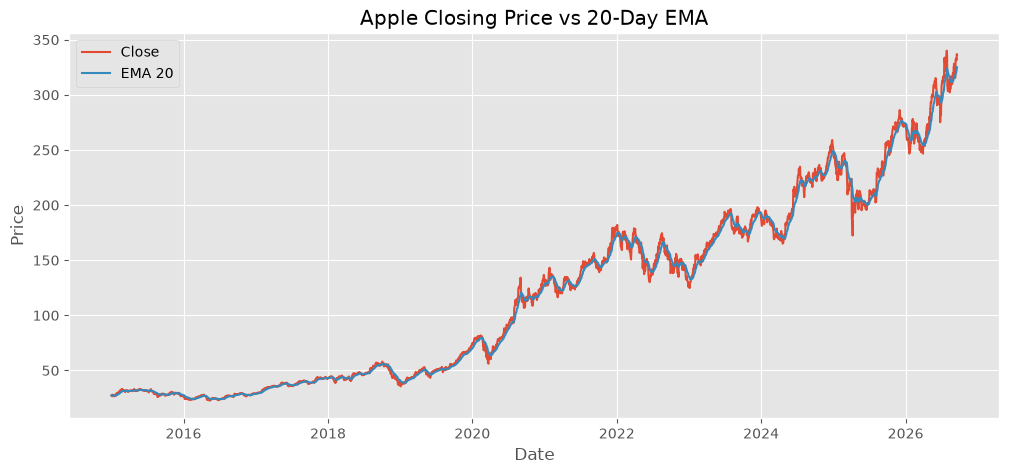

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["EMA_20"], label="EMA 20")

plt.title("Apple Closing Price vs 20-Day EMA")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

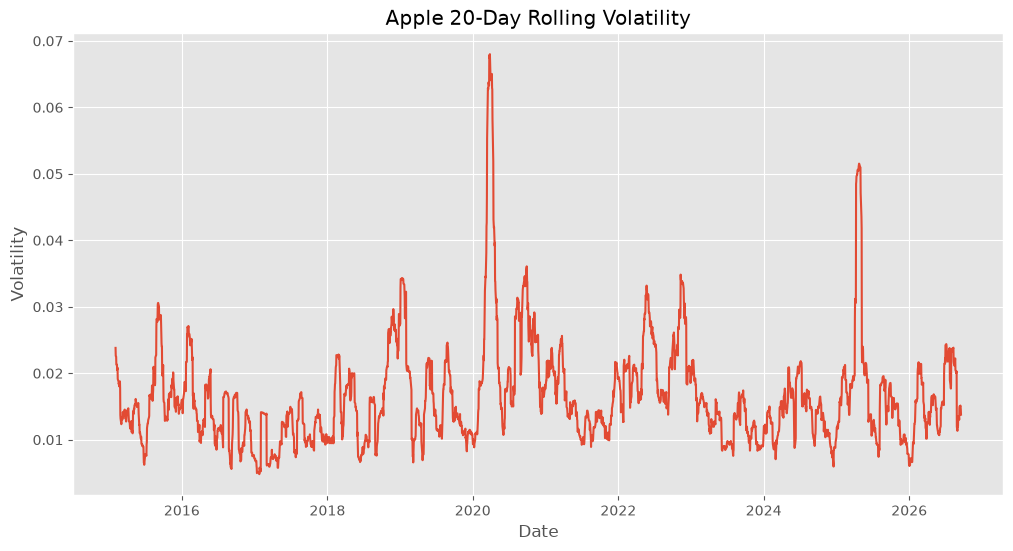

In [32]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Volatility_20"])
plt.title("Apple 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

## Conclusion

Feature engineering was successfully applied to all 8 US and Indian stocks using a reusable pipeline.

The engineered features capture different aspects of stock behavior, including:

- Price movement
- Historical returns
- Short-term and long-term trends
- Volatility
- Trading activity
- Intraday price behavior
- Momentum

The processed datasets are now ready for target creation and machine learning data preparation.